In [1]:
%matplotlib inline
from __future__ import print_function
import numpy
import matplotlib.pyplot as plt

# Persamaan Elliptic (Elliptic Equations)

Persamaan eliptik berdimensi lebih tinggi pada umumnya memiliki bentuk

$$
    a_1 u_{xx} + a_2 u_{xy} + a_3 u_{yy} + a_4 u_x + a_5 u_y + a_6 u = f
$$

Klasifikasi ini berasal dari bentuk umum PDE orde dua yang merupakan bagian pentingnya adalah turunan orde dua:

$$a_1 u_{xx} + a_2 u_{xy} + a_3 u_{yy}$$

Bentuk ini secara matematis mirip dengan persamaan kuadrat

$$a_1 x^2 + a_2 xy + a_3 y^2$$

Diskriminan dari bentuk kuadrat tersebut adalah

$$D = a_2^2 - 4 a_1 a_3$$

Jika

$$D < 0$$

maka bentuk tersebut bersifat elliptic, sehingga PDE yang terkait juga diklasifikasikan sebagai elliptic equation.

dengan:

* $u(x,y)$ : fungsi yang ingin dicari
* $u_x, u_y$ : turunan pertama terhadap $x$ dan $y$
* $u_{xx}, u_{yy}$ : turunan kedua
* $u_{xy}$ : turunan campuran
* $a_1,\dots,a_6$ : koefisien yang bisa berupa konstanta atau fungsi dari $x,y$
* $f(x,y)$ : fungsi sumber (source term)

di mana koefisien-koefisiennya harus memenuhi

$$
    a_2^2 - 4 a_1 a_3 < 0.
$$

Syarat ini berasal dari klasifikasi PDE orde dua, yang membagi PDE menjadi tiga jenis:

| Jenis PDE  | Syarat               |
| ---------- | -------------------- |
| Elliptic   | $a_2^2 - 4a_1a_3 <0$ |
| Parabolic  | $a_2^2 - 4a_1a_3 =0$ |
| Hyperbolic | $a_2^2 - 4a_1a_3 >0$ |


Salah satu tempat alami di mana persamaan seperti ini kembali muncul adalah pada masalah keadaan tunak (steady-state) yang berasal dari heat equation. Dalam dua dimensi kita memiliki

$$
    u_t = (\kappa u_x)_x + (\kappa u_y)_y + \Psi(x,y).
$$

* $u(x,y,t)$ = suhu
* $\kappa$ = konduktivitas termal
* $\Psi(x,y)$ = sumber panas
* $u_t$ = perubahan suhu terhadap waktu

Jika sistem mencapai steady state, maka suhu tidak berubah terhadap waktu menghasilkan $u_t = 0$ maka diperoleh

$$
    (\kappa u_x)_x + (\kappa u_y)_y = -\Psi(x,y).
$$

Pada keadaan steady state

$$u_t = 0$$

sehingga

$$0 = (\kappa u_x)_x + (\kappa u_y)_y + \Psi(x,y)$$

Pindahkan $\Psi(x,y)$ ke ruas kanan

$$(\kappa u_x)_x + (\kappa u_y)_y = -\Psi(x,y)$$

Ini adalah bentuk umum elliptic PDE untuk distribusi suhu steady-state.


Jika kita mengasumsikan konduktivitas termal $\kappa$ konstan, maka

$$(\kappa u_x)*x = \kappa u*{xx}$$

dan

$$(\kappa u_y)*y = \kappa u*{yy}$$

Sehingga persamaan sebelumnya menjadi

$$\kappa u_{xx} + \kappa u_{yy} = -\Psi(x,y)$$

Kemudian bagi dengan $\kappa$

$$u_{xx} + u_{yy} = -\frac{\Psi}{\kappa}$$

Jika kita definisikan

$$f(x,y) = -\frac{\Psi}{\kappa}$$

Atau 

$$
    u_{xx} + u_{yy} = -\frac{\Psi}{\kappa} = f(x,y)
$$

yang merupakan bentuk berdimensi lebih tinggi dari persamaan Poisson ($\nabla^2 u = f(x,y)$ dan persamaan Laplace jika $f(x,y) = 0$).

Kita juga harus menentukan suatu domain $\Omega$ dan kondisi batas seperti sebelumnya. Sekarang kondisi batas akan memiliki ketergantungan pada $x$ dan $y$ sehingga perlu ditangani sedikit berbeda dibandingkan sebelumnya.

## 5-Point Stencil

Dalam metode numerik untuk persamaan elliptic, khususnya persamaan Poisson dan persamaan Laplace, operator yang paling penting adalah Laplacian. Mulai dengan turunan yang diperoleh dari aproksimasi turunan kedua dengan central difference. Dimana turunan kedua terhadap $x$

Dari ekspansi Taylor diperoleh pendekatan

$$u_{xx}(x_i,y_j)
\approx
\frac{U_{i-1,j}-2U_{i,j}+U_{i+1,j}}{\Delta x^2}$$

Lalu turunan kedua terhadap $y$

Dengan cara yang sama diperoleh

$$u_{yy}(x_i,y_j)
\approx
\frac{U_{i,j-1}-2U_{i,j}+U_{i,j+1}}{\Delta y^2}$$

Karena dalam dua dimensi operator Laplacian ditulis sebagai

$$\nabla^2 u = u_{xx} + u_{yy}$$

Untuk menyelesaikan persamaan ini secara numerik, domain dibagi menjadi grid diskret dengan titik-titik

$$(x_i, y_j)$$

dan nilai fungsi pada titik tersebut ditulis sebagai

$$U_{i,j} \approx u(x_i,y_j)$$

Turunan kedua kemudian dihampiri menggunakan finite difference pusat (central difference).

Pendekatan ini menghasilkan skema yang disebut 5-Point Stencil, karena nilai suatu titik dihitung menggunakan empat titik tetangganya (kiri, kanan, atas, bawah)

Secara numerik Laplacian dapat dihampiri sebagai

$$\nabla^2 u \approx \frac{U_{i-1,j}-2U_{i,j}+U_{i+1,j}}{\Delta x^2}+\frac{U_{i,j-1}-2U_{i,j}+U_{i,j+1}}{\Delta y^2}$$

Jika ukuran grid sama pada kedua arah

$$\Delta x = \Delta y$$

maka persamaan tersebut dapat disederhanakan menjadi

$$\nabla^2 u \approx
\frac{
U_{i-1,j}+U_{i+1,j}-4U_{i,j}+U_{i,j-1}+U_{i,j+1}
}{\Delta x^2}$$


Persamaan Poisson dalam dua dimensi sendiri adalah

$$\nabla^2 u = f(x,y)$$

Dengan menggunakan pendekatan 5-point stencil, persamaan tersebut menjadi

$$\frac{U_{i-1,j}+U_{i+1,j}-4U_{i,j}+U_{i,j-1}+U_{i,j+1}}{\Delta x^2} = f_{i,j}$$

di mana

$$f_{i,j} = f(x_i,y_j)$$

Jika terdapat grid berukuran $m \times m$ maka akan terdapat

$$m^2$$

titik grid yang nilainya tidak diketahui, akibatnya kita memperoleh $m^2$ persamaan linear untuk $m^2$ variabel tak diketahui. Sistem ini kemudian diselesaikan menggunakan metode seperti Jacobi, Gauss-Seidel, Successive Over Relaxation (SOR)


Kita kemudian dapat mengaproksimasi solusi dari persamaan Poisson sebagai
$$
    \frac{U_{i-1,j} + U_{i+1,j} - 4 U_{i,j}  + U_{i,j-1} + U_{i,j+1}}{\Delta x^2} = f_{i,j}
$$
yang menghasilkan $m^2$ persamaan untuk $m^2$ variabel tak diketahui.

## Pengurutan Variabel Tak Diketahui (Ordering of Unknowns)

Pada penyelesaian numerik persamaan Poisson atau Laplace dalam dua dimensi, domain dibagi menjadi grid titik-titik diskret. Pada grid tersebut terdapat dua jenis titik:

* Titik batas (boundary) → nilainya sudah diketahui dari boundary condition (ditunjukkan warna biru pada gambar).
* Titik interior → nilainya belum diketahui dan harus dihitung (ditunjukkan warna merah).

Nilai solusi pada setiap titik grid dinyatakan sebagai

$$U_{i,j} \approx u(x_i,y_j)$$

Jika grid memiliki ukuran $m \times m$, maka nilai solusi dapat dituliskan dalam bentuk array dua dimensi. Kita dapat menganggap masalah dua dimensi kita berada pada sebuah grid seperti pada gambar berikut. Di sini variabel tak diketahui berwarna merah dan batasnya berwarna biru:

![Grid](2%20Grid.png)

Kita dapat menganggap grid tersebut sebagai sebuah matriks seperti
$$
    U = \begin{bmatrix}
        U_{1, m}   & U_{2, m}   & \cdots & U_{m-1, m}   & U_{m,m}    \\
        U_{1, m-1} & U_{2, m-1} & \cdots & U_{m-1, m-1} & U_{m, m-1} \\
        \vdots & & & & \vdots \\
        U_{1, 2} & U_{2, 2}     & \cdots & U_{m-1, 2}   & U_{m, 2}   \\
        U_{1, 1} & U_{2, 1}     & \cdots & U_{m-1, 1}   & U_{m, 1}   \\
    \end{bmatrix}
$$
Penting untuk dicatat bahwa pelabelan ini tidak sesuai dengan notasi matriks yang biasa kita gunakan!

Pada implementasi komputasi, sistem persamaan harus dituliskan dalam bentuk

$$AU=b$$

Namun metode aljabar linear hanya bekerja dengan vektor satu dimensi, sehingga array dua dimensi harus diubah menjadi vektor satu dimensi. Proses ini disebut ordering of unknowns.

Ketika kita memiliki satu dimensi, pengurutan variabel tak diketahui (dan persamaan) cukup jelas, tetapi sekarang kita memiliki sejumlah pilihan yang harus dibuat. Mungkin pilihan yang paling jelas adalah memecah array 2d menjadi baris-baris dan menambahkan masing-masing ke akhir dari baris sebelumnya. Ini menghasilkan pengurutan

$$
    U = [U_{1, 1}, U_{2, 1}, \ldots, U_{m-1,1}, U_{m, 1}, U_{1, 2}, U_{22},\ldots, U_{m-1,m}, U_{mm}]
$$

Artinya kita membaca baris pertama kemudian baris kedua dan seterusnya hingga baris terakhir. Sekarang cobalah lihat apakah kamu dapat menentukan struktur dari matriks $A$ sekarang dengan pengurutan ini.

Jika semua persamaan tersusun pada seluruh titik interior, kita memperoleh sistem $AU=b$ dengan struktur matriks khusus.

Struktur Matriks $A$ yang memiliki bentuk block tridiagonal

$$A =
\frac{1}{\Delta x^2}
\begin{bmatrix}
T & I \\
I & T & I \\
& I & T & I \\
& & \ddots & \ddots & \ddots \\
& & & I & T & I \\
& & & & I & T
\end{bmatrix}$$

$T$ adalah matriks tridiagonal Matriks (T) berasal dari hubungan antar titik dalam arah horizontal. Sedangkan $I$ adalah matriks identitas

$$T =
\begin{bmatrix}
-4 & 1 \\
1 & -4 & 1 \\
& 1 & -4 & 1 \\
& & \ddots & \ddots & \ddots \\
& & & 1 & -4 & 1 \\
& & & & 1 & -4
\end{bmatrix}$$

Interpretasi koefisien:

* -4 merupakan kontribusi titik pusat
* 1 merupakan kontribusi tetangga kiri dan kanan

Sedangkan matriks identitas $I$ merepresentasikan hubungan dengan titik atas dan bawah pada grid. Dengan demikian matriks $A$ menyimpan seluruh hubungan tetangga dalam skema 5-point stencil.

Kemungkinan lain adalah pengurutan red-black atau dalam bahasa inggris Red-Black Ordering (seperti papan catur). Di sini kita “mewarnai” setiap variabel tak diketahui pada grid kita dengan warna yang berselang-seling atau bergantian, kemudian setiap variabel tak diketahui dengan warna yang sama dikelompokkan bersama misal saja merah dan hitam.  

![Red Black](2D%20Grid%20Red-Black%20Ordering.png)


Ciri penting dari pola ini adalah:

* Setiap titik merah hanya bertetangga dengan titik hitam
* Setiap titik hitam hanya bertetangga dengan titik merah

Dengan demikian semua variabel dapat dikelompokkan menjadi dua kelompok besar:

$$U =
\begin{bmatrix}
U_{\text{red}} \
U_{\text{black}}
\end{bmatrix}$$

Metode ini sering digunakan dalam Gauss-Seidel iteration, multigrid methods, dan parallel computing karena pembaruan nilai dapat dilakukan secara bergantian antara red dan black nodes.

Dengan pengurutan red–black, sistem persamaan linear $AU = f$ maka akan diperoleh matkris seperti berikut
$$
    \begin{bmatrix}
        D & H \\
        H^T & D
    \end{bmatrix} \begin{bmatrix}
        U_{\text{red}} \\
        U_{\text{black}}
    \end{bmatrix} =
    \begin{bmatrix}
        f_{\text{red}} \\
        f_{\text{black}}
    \end{bmatrix}
$$
Di sini $D = -4 / \Delta x^2 I$, sebuah matriks diagonal dengan dimensi $m^2 / 2$ dan $H$ sebuah banded matrix dengan 4 diagonal tak nol. Dengan $U_{\text{red}}$ merupakan variabel pada node merah, dan $U_{\text{black}}$ merupakan variabel pada node hitam


Biasanya tujuan dari pengurutan adalah untuk membuat jarak antara elemen tak nol sekecil mungkin dan mengurangi jumlah “fill-in” ketika menyelesaikan persamaan menggunakan misalnya eliminasi Gaussian. Hal ini sering kali ditangani secara otomatis ketika menggunakan prosedur penyelesaian yang lebih canggih.

Selesaikan PDE berikut menggunakan pengurutan pilihanmu:
$$
    \nabla^2 u = -2\sin x \sin y \quad \Omega = [0, 2 \pi] \times [0 , 2 \pi] \\
    u(x,0) = 0, u(x, 2 \pi) = 0, u(0, y) = 0, u(2 \pi, y) = 0.
$$

0.0012900074949949803


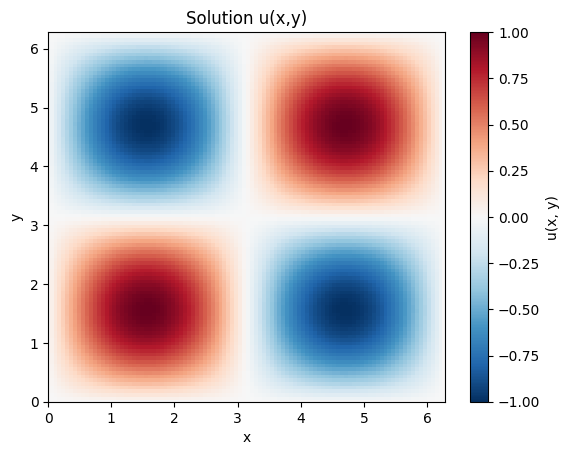

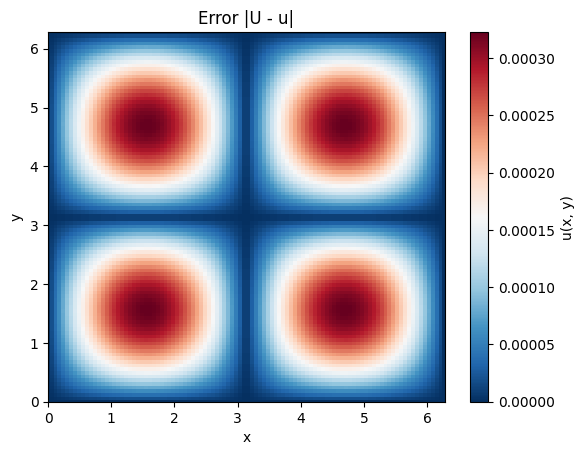

In [2]:
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg

# Problem specification
m = 100
x = numpy.linspace(0, 2.0 * numpy.pi, m + 2)
y = numpy.linspace(0, 2.0 * numpy.pi, m + 2)
delta_x = 2.0 * numpy.pi / (m + 1)

# Construct A
e = numpy.ones(m)
T = sparse.spdiags([e, -4.0 * e, e], [-1, 0, 1], m, m)
S = sparse.spdiags([e, e], [-1, 1], m, m)
I = sparse.eye(m)
A = sparse.kron(I, T) + sparse.kron(S, I)
A /= delta_x**2

# Right-hand-side
X, Y = numpy.meshgrid(x[1:-1], y[1:-1])
f = -2.0 * numpy.sin(X) * numpy.sin(Y)

# Solve
U = numpy.zeros((m+2, m+2))
U[1:-1, 1:-1] = linalg.spsolve(A, f.reshape(m**2, order='F')).reshape((m, m), order='F')

# Error
X, Y = numpy.meshgrid(x, y)
print(numpy.linalg.norm((x[1] - x[0]) * (U - numpy.sin(X) * numpy.sin(Y)), ord=1))

# Plot solution
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
sol_plot = axes.pcolor(X, Y, U, cmap=plt.get_cmap('RdBu_r'))
axes.set_title("Solution u(x,y)")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.set_xlim((0.0, 2.0 * numpy.pi))
axes.set_ylim((0.0, 2.0 * numpy.pi))
cbar = fig.colorbar(sol_plot, ax=axes)
cbar.set_label("u(x, y)")

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
sol_plot = axes.pcolor(X, Y, numpy.abs(U - numpy.sin(X) * numpy.sin(Y)), cmap=plt.get_cmap('RdBu_r'))
axes.set_title("Error |U - u|")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.set_xlim((0.0, 2.0 * numpy.pi))
axes.set_ylim((0.0, 2.0 * numpy.pi))
cbar = fig.colorbar(sol_plot, ax=axes)
cbar.set_label("u(x, y)")
plt.show()

## Akurasi dan Stabilitas (Accuracy and Stability)

Tentu saja kita dapat (dan seharusnya) mengajukan pertanyaan yang sama seperti pada kasus satu dimensi, yaitu apakah skema kita akan konvergen. Untuk melakukan ini kita perlu mempertimbangkan LTE (Local Truncation Error) yaitu mengukur diskretisasi dan stabilitas yaitu memastikan error tidak berkembang secara tidak terkendali. Untuk skema 5-point stencil pada persamaan Poisson $\nabla^2 u = f$ aproksimasi diskretnya adalah

$$\frac{u(x_{i-1},y_j)+u(x_{i+1},y_j)+u(x_i,y_{j-1})+u(x_i,y_{j+1})-4u(x_i,y_j)}{\Delta x^2}$$

Local truncation error didefinisikan sebagai selisih antara operator diskret dengan persamaan PDE yang sebenarnya ketika solusi eksak dimasukkan ke skema numerik.

$$\begin{aligned}
    \tau_{ij} &= \frac{1}{\Delta x^2} (u(x_{i-1}, y_{j}) + u(x_{i+1}, y_{j}) + u(x_{i}, y_{j-1}) + u(x_{i}, y_{j+1}) - 4 u(x_{i}, y_{j})) - f(x_i, y_j)
\end{aligned}$$

Untuk mengetahui berapa besar error dari aproksimasi ini, kita menuliskan nilai fungsi di titik-titik tetangga menggunakan deret Taylor di sekitar titik pusat $(x_i,y_j)$.

Untuk menghitung ekspresi ini kita memerlukan deret Taylor pada setiap arah.

Untuk arah x:
$$\begin{aligned}
    u(x_{i+1}, y_{j}) &= u(x_{i}, y_{j}) + \Delta x u(x_{i}, y_{j})_x + \frac{\Delta x^2}{2} u(x_{i}, y_{j})_{xx} + \frac{\Delta x^3}{6} u(x_{i}, y_{j})_{xxx} + \frac{\Delta x^4}{24} u(x_{i}, y_{j})_{xxxx} + \mathcal{O}(\Delta x^5) \\
    u(x_{i-1}, y_{j}) &= u(x_{i}, y_{j}) - \Delta x u(x_{i}, y_{j})_x + \frac{\Delta x^2}{2} u(x_{i}, y_{j})_{xx} - \frac{\Delta^3}{6} u(x_{i}, y_{j})_{xxx} + \frac{\Delta x^4}{24} u(x_{i}, y_{j})_{xxxx} + \mathcal{O}(\Delta x^5)
\end{aligned}$$

Untuk arah y:
$$\begin{aligned}
    u(x_{i}, y_{j+1}) &= u(x_{i}, y_{j}) + \Delta y u(x_{i}, y_{j})_y + \frac{\Delta y^2}{2} u(x_{i}, y_{j})_{yy} + \frac{\Delta y^3}{6} u(x_{i}, y_{j})_{yyy} + \frac{\Delta y^4}{24} u(x_{i}, y_{j})_{yyyy} + \mathcal{O}(\Delta y^5) \\
    u(x_{i}, y_{j-1}) &= u(x_{i}, y_{j}) - \Delta y u(x_{i}, y_{j})_y + \frac{\Delta y^2}{2} u(x_{i}, y_{j})_{yy} - \frac{\Delta y^3}{6} u(x_{i}, y_{j})_{yyy} + \frac{\Delta y^4}{24} u(x_{i}, y_{j})_{yyyy} + \mathcal{O}(\Delta y^5)
\end{aligned}$$

Dengan menggunakan juga ekspansi Taylor pada arah y, kemudian memasukkan hasil tersebut ke dalam definisi LTE, kita dapat menuliskan LTE sebagai
$$
    \tau_{ij} =  \frac{1}{12} \Delta x^2 (u_{xxxx} + u_{yyyy}) + \mathcal{O}(\Delta x^4).
$$

Persamaan ini menunjukkan bahwa error lokal dari skema numerik bergantung pada turunan keempat dari fungsi. Menandakan error utama berorde $\Delta x^2$ ($\Delta x^2 (u_{xxxx}+u_{yyyy})$) dan suku berikutnya berorde $\Delta x^4$ yang jauh lebih kecil ketika grid diperkecil. Artinya metode 5-point stencil memiliki akurasi orde dua.


Sistem linear untuk LTE kemudian memiliki bentuk
$$
    A_{\Delta x} E_{\Delta x} = -\tau_{\Delta x}
$$
di mana sekarang $A$ adalah diskretisasi yang kita tuliskan sebelumnya, $E_{\Delta x}$ adalah vektor error solusi, dan $\tau_{\Delta x}$ adalah vektor truncation error. Perhatikan bahwa pengurutan persamaan tidak berpengaruh ketika mempertimbangkan galat. Artinya walaupun kita mengubah cara menyusun grid menjadi vektor, sifat error tetap sama.

Untuk stabilitas dalam norma 2 kita kembali dapat mempertimbangkan nilai eigen dari sistem di atas. Nilai eigennya adalah
$$
    \lambda_{pq} = \frac{2}{\Delta x^2} ((\cos(p \pi \Delta x) - 1) + (\cos(q \pi \Delta x) - 1))
$$
dengan vektor eigen yang bersesuaian
$$
    v^{p,q}_{ij} = \sin(p \pi i \Delta x) \sin(q \pi j \Delta x).
$$

Vektor eigen ini berbentuk fungsi sinus, yang sering muncul pada solusi PDE dengan boundary condition nol.

Karena nilai eigen tersebut bernilai negatif secara ketat ($A$ sebenarnya negatif definit) maka yang paling dekat dengan titik asal adalah
$$
    \lambda_{11} = -2 \pi^2 + \mathcal{O}(\Delta x^2)
$$

Nilai ini penting karena menentukan radius spektral dari matriks invers yang menghasilkan radius spektral

$$
    \rho((A^{\Delta x})^{-1}) = \frac{1}{\lambda_{11}} \approx -\frac{1}{2 \pi^2}.
$$

Kita kemudian dapat menggunakan batas ini pada $A^{-1}$ untuk menunjukkan stabilitas dan dengan demikian konvergensi dari diskretisasi tersebut.

Besaran lain yang serupa dan berguna untuk dipertimbangkan adalah condition number dari matriks $A$. Condition number mengukur sensitivitas solusi terhadap error numerik. Ingat bahwa ini dapat didefinisikan sebagai
$$
    \kappa(A) = ||A|| ||A^{-1}||.
$$

Dalam norma 2 kita sudah mengetahui beberapa informasi tentang $A^{-1}$ tetapi kita dapat menggunakan ekspresi kita dari sebelumnya untuk juga menemukan radius spektral dari $A$. Nilai eigen terbesar di sana adalah
$$
    \lambda_{mm} \approx -\frac{8}{\Delta x^2}
$$
yang menghasilkan condition number
$$
    \kappa_2(A) = \frac{4}{\pi^2 \Delta x^2} = \mathcal{O}\left(\frac{1}{\Delta x^2}\right)
$$
Oleh karena itu matriks ini menjadi semakin tidak terkondisi dengan baik dan condition number meningkat ketika $\Delta x \rightarrow 0$.

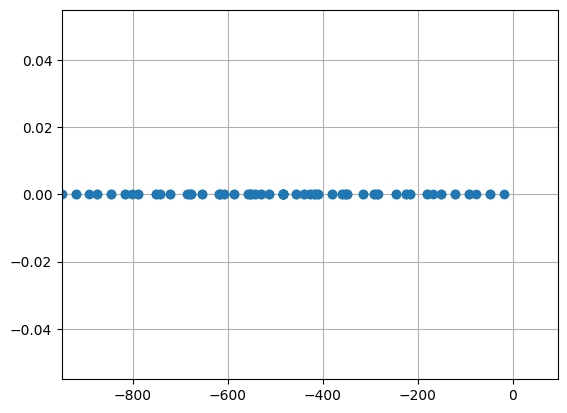

In [3]:
# Compute the eigenvalues
m = 10
delta_x = 1.0 / float(m + 1)
eig_vals = numpy.empty(m**2)
for (i, p) in enumerate(numpy.arange(1, m + 1)):
    for (j, q) in enumerate(numpy.arange(1, m + 1)):
        eig_vals[i * m + j] = 2.0 / delta_x**2 * ((numpy.cos(p * numpy.pi * delta_x) - 1.0) +
                                                  (numpy.cos(q * numpy.pi * delta_x) - 1.0))

# Plot of the eigenvalues of the 5-point Laplacian
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(eig_vals.real, eig_vals.imag, 'o')
axes.grid(True)
axes.set_xlim(numpy.amin(eig_vals), -numpy.amin(eig_vals) * 0.1)
plt.show()

## 9-Point Laplacian

Pada diskretisasi sebelumnya kita menggunakan 5-point stencil untuk menghampiri operator Laplacian:

$$\nabla^2 u = u_{xx} + u_{yy}$$

Namun ada pendekatan lain yang lebih akurat untuk mendiskretisasi Laplacian $\nabla^2$ disebut stencil 9-titik atau 9-point stencil. Pada metode ini kita tidak hanya menggunakan titik kiri, kanan, atas, dan bawah. Tetapi juga empat titik diagonal di sekitar titik pusat. Stencil ini didefinisikan sebagai

$$
    \nabla^2 u_{ij} = \frac{1}{6 \Delta x^2} \left(4 u_{i-1,j} + 4 u_{i+1,j} + 4 u_{i,j-1} + 4 u_{i,j+1} + u_{i-1,j-1} + u_{i+1,j-1} + u_{i+1,j+1} + u_{i-1,j+1} -20 u_{i,j}  \right).
$$

Artinya:

* Titik horizontal dan vertikal diberi bobot 4
* Titik diagonal diberi bobot 1
* Titik pusat diberi bobot −20

Kemudian seluruhnya dibagi oleh $6\Delta x^2$. Metode ini menggunakan 9 titik grid, sehingga disebut 9-point stencil.


Kita juga dapat menemukan LTE seperti sebelumnya sehingga diperoleh
$$
    \tau_{ij} = \frac{\Delta x^2}{12} (u_{xxxx} + 2u_{xxyy} + u_{yyyy}) + \mathcal{O}(\Delta x^4).
$$

Error utama tetap berorde $\Delta x^2$, tetapi bentuknya lebih simetris terhadap $x$ dan $y$. Perbedaan utama dari metode sebelumnya adalah munculnya suku campuran $u_{xxyy}$ yang berasal dari kontribusi titik diagonal.

Jadi apa yang kita peroleh? Jika kita melihat $\tau_{ij}$ kita sebenarnya dapat menuliskan suku turunan tersebut sebagai
$$
    u_{xxxx} + 2u_{xxyy} + u_{yyyy} = \nabla^2 (\nabla^2 u) \equiv \nabla^4 u,
$$
yaitu Laplacian dari Laplacian (disebut operator biharmonik). Operator ini berarti Laplacian dari Laplacian. Jika kita kembali ke PDE semula, kita dapat secara langsung menemukan bentuk galat ini dengan memperhatikan

$$\begin{aligned}
    \nabla^2 u &= f \\
    \nabla^2 (\nabla^2 u) &= \nabla^2 f
\end{aligned}$$

Ini berarti $\nabla^4 u = \nabla^2 f$ Sehingga suku error dapat langsung ditulis menggunakan fungsi $f$. Oleh karena itu kita dapat menghitung suku-suku galat secara langsung dengan mengambil Laplacian dari ruas kanan PDE semula.

Jika kita tahu bahwa error mengandung suku

$$\frac{\Delta x^2}{12}\nabla^2 f$$

Maka hal ini juga dapat menghasilkan metode dengan orde yang lebih tinggi. Jika kita mendefinisikan
$$
    f_{ij} = f(x_i, y_j) + \frac{\Delta x^2}{12} \nabla^2 f(x_i, y_j)
$$
kita dapat meniadakan suku berikutnya dari LTE! Kita bahkan dapat melakukan ini jika kita hanya memiliki fungsi $f(x,y)$ pada sekumpulan titik diskret karena kita dapat menggunakan stencil 5-titik.